<a href="https://colab.research.google.com/github/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/blob/main/1D_heat_forward_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Set random to ensure reproduceability

In [ ]:
# Set the global random seed
dde.config.set_random_seed(42)

# Import necessary modules

In [ ]:
pip install deepxde

In [ ]:
import os

os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np

In [ ]:
import numpy as np

# Define the system

Define PDE

In [ ]:
def pde(x, y):
    '''
    x: input tensor containing domain coordinates
    x[:,0] - spatial coordinates s
    x[:,1] - time coordinates t

    y: Network prediction for the target variable u(x, t)
    '''
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    alpha = 0.01

    '''
    i, j are the indexes of x and y respectively
    dy_t = dy/dt
    dy_xx = d2y/dx2
    '''
    return dy_t - alpha * dy_xx # residual

Define our System (Spatial and Temporal Doamain)

In [ ]:
# Spatial domain: x in [0, 1]
# Time domain: t in [0, 20]
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 20)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

Define Boundary and Initial Conditions

In [ ]:
# Boundary Condtion (Walls at x=0 and x=1 are at 100 degrees)
def boundary(x, on_boundary):
    return on_boundary and (np.isclose(x[0], 0.0) or np.isclose(x[0], 1.0))

bc = dde.icbc.DirichletBC(geomtime, lambda x: 100.0, boundary)

initial_smooth(x) (Continuous Gradient): This introduces an exponential decay function to blend the temperatures. Instead of a hard step, the temperature is 100 degrees at the very edges and rapidly but smoothly curves down to 25 degrees just inside the bar.

By eliminating the mathematical discontinuity, the loss landscape becomes much smoother, making it significantly easier for the neural network's optimizer to converge accurately.

In [ ]:
def initial_smooth(x):
    # x[:, 0:1] extracts the spatial coordinates.
    # The exponentials create a steep gradient from 100 at the edges down to 25.
    x_pos = x[:, 0:1]
    return 25.0 + 75.0 * (np.exp(-150 * x_pos) + np.exp(-150 * (1 - x_pos)))

ic = dde.icbc.IC(geomtime, initial_smooth, lambda _, on_init: on_init)

Combine into DeepXDE TimePDE data structure


In [ ]:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=10000, # Increased for better spatial-temporal resolution
    num_boundary=500, # Increased to strictly enforce wall temperatures
    num_initial=500,  # Increased to capture the steep initial gradient
    train_distribution="Hammersley"
)

# Define and Train the NN

Neural Network Architecture

Apply an Output Transform (Scaling)
Force the network to naturally output values in the 25–100 range without forcing the internal weights to artificially inflate. Apply a linear transformation directly to the network's output right after defining it:

In [ ]:
# 2 inputs (x, t), 1 output (u)
net = dde.nn.FNN([2] + [40] * 4 + [1], "tanh", "Glorot normal")

# Shift and scale the network output to better match the 25-100 range.
# This prevents the tanh layers from having to learn massive weights.
net.apply_output_transform(lambda x, y: y * 50.0 + 50.0)

model = dde.Model(data, net)

Why y * 50.0 + 50.0 specifically?

The formula y * 50.0 + 50.0 maps the network's $[-1, 1]$ output to the range $[0, 100]$:

$y = -1 \implies u = (-1)(50) + 50 = 0^\circ\text{C}$When $y = 0 \implies u = (0)(50) + 50 = 50^\circ\text{C}$When $y = 1 \implies u = (1)(50) + 50 = 100^\circ\text{C}$

Compile and Train

In [ ]:
# Reduces the learning rate exponentially every step using a gamma multiplier
model.compile("adam", lr=1e-3, loss_weights=[1, 10, 10]) # PDE, BC, IC losses respectively
model.train(iterations=15000, display_every=1000)


Compiling model...
'compile' took 0.000259 s

Training model...

0         [5.84e+00, 4.13e+04, 5.52e+03]    [5.84e+00, 4.13e+04, 5.52e+03]    []  
1000      [3.76e+02, 4.60e+02, 2.28e+02]    [3.76e+02, 4.60e+02, 2.28e+02]    []  
2000      [7.62e+01, 1.29e+02, 1.20e+02]    [7.62e+01, 1.29e+02, 1.20e+02]    []  
3000      [1.67e+01, 2.66e+01, 5.26e+01]    [1.67e+01, 2.66e+01, 5.26e+01]    []  
4000      [6.72e+00, 6.11e+00, 2.96e+01]    [6.72e+00, 6.11e+00, 2.96e+01]    []  
5000      [6.44e+00, 4.66e+01, 2.68e+01]    [6.44e+00, 4.66e+01, 2.68e+01]    []  
6000      [2.93e+00, 9.96e-01, 1.24e+01]    [2.93e+00, 9.96e-01, 1.24e+01]    []  
7000      [2.27e+00, 5.28e-01, 8.11e+00]    [2.27e+00, 5.28e-01, 8.11e+00]    []  
8000      [1.81e+00, 4.77e-01, 6.02e+00]    [1.81e+00, 4.77e-01, 6.02e+00]    []  
9000      [1.51e+00, 2.94e-01, 4.69e+00]    [1.51e+00, 2.94e-01, 4.69e+00]    []  
10000     [1.63e+00, 2.20e-01, 3.79e+00]    [1.63e+00, 2.20e-01, 3.79e+00]    []  
11000     [1.97e+00, 4

(<deepxde.model.LossHistory at 0x7ae3d1931a90>,
 <deepxde.model.TrainState at 0x7ae3d1931950>)

In [ ]:
# Standard DeepXDE compilation for L-BFGS
model.compile("L-BFGS")

# Pass iterations as the maximum step cap
losshistory, train_state = model.train(iterations=5000)

Compiling model...
'compile' took 0.000551 s

Training model...

Step      Train loss                        Test loss                         Test metric
15000     [7.50e-01, 6.69e-03, 1.98e-01]    [7.50e-01, 6.69e-03, 1.98e-01]    []  
16000     [6.00e-02, 8.76e-03, 4.11e-02]    [6.00e-02, 8.76e-03, 4.11e-02]    []  
17000     [2.18e-02, 2.03e-03, 9.76e-03]    [2.18e-02, 2.03e-03, 9.76e-03]    []  
18000     [1.31e-02, 6.91e-04, 5.31e-03]    [1.31e-02, 6.91e-04, 5.31e-03]    []  
18523     [1.00e-02, 5.99e-04, 4.33e-03]    [1.00e-02, 5.99e-04, 4.33e-03]    []  

Best model at step 18523:
  train loss: 1.50e-02
  test loss: 1.50e-02
  test metric: []

'train' took 99.719824 s



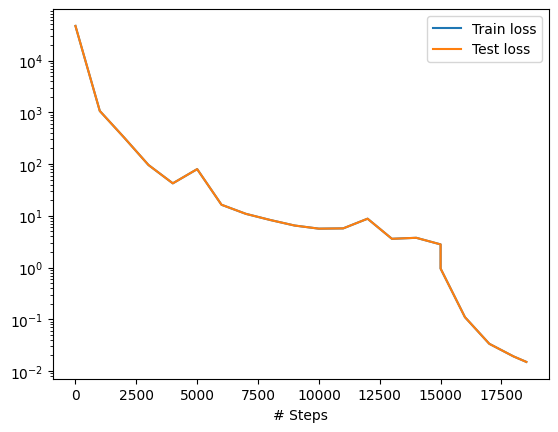

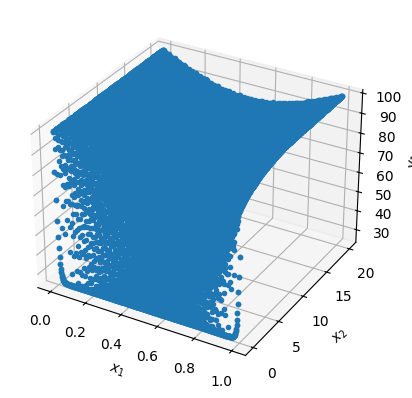

In [ ]:
# Plot training loss convergence and boundary state
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

# Save the model

In [ ]:
# Save the model weights and architecture state
model.save("fpinn_model_v3")

'fpinn_model_v3-18523.pt'

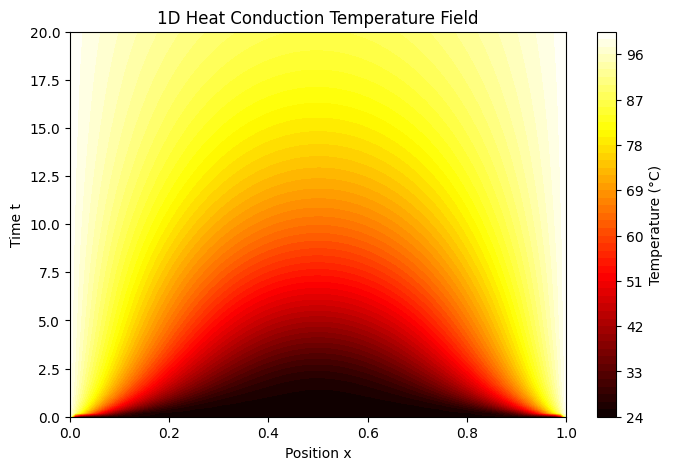

In [ ]:
import matplotlib.pyplot as plt

# Generate a dense evaluation grid
x_space = np.linspace(0, 1, 100)
t_space = np.linspace(0, 20, 100)
X, T = np.meshgrid(x_space, t_space)

# Prepare inputs for model prediction: shape (10000, 2)
X_test = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_pred = model.predict(X_test).reshape(100, 100)

# Plot 2D Contour
plt.figure(figsize=(8, 5))
contour = plt.contourf(X, T, u_pred, levels=50, cmap="hot")
plt.colorbar(contour, label="Temperature (°C)")
plt.xlabel("Position x")
plt.ylabel("Time t")
plt.title("1D Heat Conduction Temperature Field")
plt.show()